# UTS DATA MINING
## **Wine Quality Analysis**

### **Konteks**
Dataset ini berisi informasi fisikokimia dari anggur merah, yang digunakan untuk memprediksi kualitas anggur berdasarkan beberapa atribut yang diukur. Setiap baris dalam dataset mewakili sampel anggur dengan atribut seperti **kadar asam**, **kadar alkohol**, **pH**, **gula sisa**, dan lainnya, yang semuanya dapat memengaruhi kualitas rasa anggur. Data ini mencakup dua set data: **data pelatihan** dan **data pengujian**. Tujuannya adalah untuk membangun model prediksi yang dapat memperkirakan kualitas anggur berdasarkan fitur-fitur ini.

### **Problem Statement**

Kualitas anggur sering kali dievaluasi melalui tes sensorik oleh para ahli, namun ini bisa bersifat subjektif dan memerlukan banyak waktu. Oleh karena itu, dibutuhkan sistem prediksi yang dapat secara otomatis memprediksi kualitas anggur berdasarkan data kimia. Hal ini akan memungkinkan industri anggur untuk meningkatkan efisiensi produksi dan menjaga konsistensi kualitas produk.

**Problem Statement**:
"Tantangan yang dihadapi adalah bagaimana membangun model yang dapat memprediksi kualitas anggur secara otomatis berdasarkan data fisikokimia yang tersedia. Dengan dataset ini, perusahaan anggur dapat memanfaatkan model prediksi untuk meningkatkan kualitas produk dan mengoptimalkan proses produksi anggur."

### **Tujuan Analisis**

Tujuan utama dari analisis ini adalah untuk membangun **model prediksi kualitas anggur** berdasarkan atribut fisikokimia yang tersedia. Beberapa tujuan spesifik dari analisis ini adalah:

1. **Membangun Model Prediksi**: Menggunakan teknik machine learning untuk memprediksi kualitas anggur berdasarkan fitur seperti kadar alkohol, pH, gula sisa, dan lainnya.
2. **Evaluasi Model**: Menggunakan data pengujian untuk menguji kinerja model dalam memprediksi kualitas anggur yang sesungguhnya, dengan mengukur akurasi dan efektivitas model.
3. **Menemukan Faktor Kunci**: Menganalisis atribut fisikokimia yang paling berpengaruh terhadap kualitas anggur, memberikan wawasan yang berguna bagi pembuat anggur untuk meningkatkan produk mereka.
4. **Optimisasi Proses Produksi**: Memberikan rekomendasi berbasis data untuk meningkatkan kualitas anggur dan mengoptimalkan proses produksi berdasarkan faktor-faktor yang ditemukan berpengaruh.

Melalui analisis ini, dengan menggunakan data pelatihan dan pengujian, diharapkan dapat dikembangkan sistem prediksi yang lebih efisien dan akurat untuk kualitas anggur. Hal ini akan memberikan manfaat besar bagi industri anggur dengan mengurangi ketergantungan pada penilaian subjektif dan meningkatkan proses produksi agar lebih konsisten dengan standar kualitas yang diinginkan.


## **DATA UNDERSTANDING**

In [99]:
#Panggil file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.stats import shapiro
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# me-non aktifkan peringatan pada python
import warnings
warnings.filterwarnings('ignore')

dataset = "/content/data_training.csv"
df = pd.read_csv(dataset)

print(df.info())

print("Summary of training data:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None
Summary of training data:
       fixed acidity  volatile acidity  citric 

Data ini menggambarkan profil anggur merah yang digunakan untuk memprediksi kualitas anggur berdasarkan berbagai atribut fisikokimia. Setiap baris dalam dataset mewakili informasi tentang satu sampel anggur, sementara setiap kolom merepresentasikan fitur atau atribut yang dapat digunakan untuk memprediksi kualitas anggur tersebut. Berikut adalah variabel-variabel yang terdapat dalam dataset:

- **Fixed Acidity**: Kadar asam tetap dalam anggur.
- **Volatile Acidity**: Kadar asam volatil (seperti asam asetat) yang dapat mempengaruhi rasa anggur.
- **Citric Acid**: Kadar asam sitrat yang berkontribusi pada rasa segar anggur.
- **Residual Sugar**: Jumlah gula yang tersisa setelah proses fermentasi.
- **Chlorides**: Kandungan klorida dalam anggur yang mempengaruhi rasa.
- **Free Sulfur Dioxide**: Kadar sulfur dioksida bebas yang berfungsi sebagai pengawet.
- **Total Sulfur Dioxide**: Kadar total sulfur dioksida, termasuk yang terikat dan bebas.
- **Density**: Kepadatan anggur yang dipengaruhi oleh kandungan alkohol dan gula.
- **pH**: Tingkat keasaman atau kebasaan anggur.
- **Sulphates**: Kandungan sulfat dalam anggur yang dapat mempengaruhi rasa dan kualitas.
- **Alcohol**: Kandungan alkohol dalam anggur yang berpengaruh pada rasa dan kualitas.
- **Quality**: Skor kualitas anggur yang diberikan oleh para ahli, berkisar antara 3 hingga 8.
- **Id**: ID unik untuk setiap sampel anggur.

Data yang dimiliki mencakup berbagai variabel yang berkaitan dengan sifat fisikokimia anggur. Setiap baris dalam dataset mewakili informasi tentang satu sampel anggur, sedangkan setiap kolom berfungsi sebagai atribut yang membantu memprediksi kualitas anggur. Variabel-variabel seperti kadar alkohol, pH, kadar gula, dan asam dapat memberikan wawasan penting mengenai karakteristik yang memengaruhi kualitas rasa anggur. Dengan memahami data ini, kita dapat mengembangkan model prediksi yang tepat untuk memprediksi kualitas anggur dan membantu produsen dalam meningkatkan kualitas produk mereka.

Berikut adalah lima baris pertama dan terakhir dari dataset.

In [14]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918
...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,6.7,1.040,0.08,2.3,0.067,19.0,32.0,0.99648,3.52,0.57,11.0,4,1467
853,8.0,0.390,0.30,1.9,0.074,32.0,84.0,0.99717,3.39,0.61,9.0,5,1533
854,7.4,0.350,0.33,2.4,0.068,9.0,26.0,0.99470,3.36,0.60,11.9,6,1580
855,7.9,0.570,0.31,2.0,0.079,10.0,79.0,0.99677,3.29,0.69,9.5,6,1216


# **DATA CLEANSING**
Sebelum memulai tahapan analisis data lebih lanjut, langkah pertama yang perlu dilakukan adalah memahami dataset secara mendalam. Hal ini mencakup pemahaman mengenai jumlah kolom, jumlah baris, tipe data, serta identifikasi missing values atau data yang hilang. Analisis terhadap missing value sangat penting karena dapat memengaruhi kualitas model yang akan dibangun. Oleh karena itu, langkah-langkah yang diambil untuk menangani missing value harus didukung oleh penjelasan empiris dan pendekatan analisis statistik yang tepat.

In [31]:
print("Missing values before handling:")
print(df.isnull().sum())

# Handle missing values: Impute numerical columns with median
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after handling:")
print(df.isnull().sum())

X = df.drop(columns='quality')
y = df['quality']

categorical_cols = df.select_dtypes(include=['object']).columns
print("\nCategorical columns:")
print(categorical_cols)

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Assuming 'quality' is the target variable
X = df_encoded.drop(['quality', 'Id'], axis=1)
y = df_encoded['quality']

# Load and prepare test data
test_data = pd.read_csv('/content/data_testing.csv')
test_data_features = test_data.drop(columns='Id')


display(X.head())
display(y.head())
display(test_data_features.head())

Missing values before handling:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing values after handling:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Categorical columns:
Index([], dtype='object')


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


,quality
0,5
1,5
2,7
3,6
4,6


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000


Tahapan yang akan dilakukan untuk memeriksa dan menangani masalah missing value serta memberikan pemahaman lebih lanjut mengenai dataset:

1. **Menampilkan Informasi Dataset**

Pada langkah pertama, kita akan menampilkan informasi dasar mengenai dataset, termasuk:
- Jumlah kolom yang ada.
- Jumlah baris dalam dataset.
- Tipe data dari masing-masing kolom.

Dengan menggunakan fungsi df.info(), kita dapat melihat apakah dataset mengandung nilai yang hilang (null/NaN) pada kolom tertentu.


2. **Mengidentifikasi Missing Values**
Kita akan memeriksa apakah ada nilai yang kosong (null/NaN) dalam dataset. Jika ada, kita akan menentukan penanganan yang tepat untuk menangani missing values tersebut. Ada beberapa pendekatan untuk menangani missing values:
- Mengisi dengan rata-rata atau median untuk kolom numerik.
- Menghapus baris atau kolom yang mengandung nilai yang hilang jika jumlahnya tidak signifikan.

Dalam dataset yang digunakan, kita melihat bahwa sebelum penanganan, tidak ada nilai yang hilang (missing value) pada semua kolom, seperti yang ditunjukkan dalam output yang diperoleh:

Karena tidak ada missing value, tidak diperlukan penanganan khusus dalam hal ini.

3. **Deskripsi Statistik Dataset**
Selanjutnya, kita akan melihat deskripsi statistik dari dataset untuk memahami distribusi data. Fungsi df.describe() memberikan informasi mengenai:
- Nilai rata-rata (mean).
- Standar deviasi (std).
- Minimum, maksimum.
- Persentil ke-25, ke-50 (median), dan ke-75.

Dengan informasi ini, kita dapat memahami rentang nilai setiap fitur dan mendeteksi kemungkinan adanya data yang tidak wajar atau imbalance dalam dataset.

4. **Identifikasi Imbalance**
Kita juga perlu memeriksa apakah terdapat ketidakseimbangan kelas dalam variabel target, misalnya jika prediksi kualitas anggur didominasi oleh satu nilai kualitas tertentu, maka model mungkin akan kesulitan untuk memprediksi kelas yang jarang. Analisis ini dapat dilakukan dengan memeriksa distribusi kelas pada kolom quality.

5. **Mendeteksi Outlier**
Selanjutnya, kita akan memeriksa apakah terdapat outlier (nilai yang jauh di luar rentang normal) yang dapat memengaruhi analisis. Outlier dapat mengganggu kestabilan model dan perlu ditangani. Visualisasi seperti box plot dapat membantu mendeteksi nilai ekstrim yang dapat dianggap sebagai outlier.

**Feature Selection dan Analisis Prediktor**

Setelah memahami dataset dan melakukan pembersihan, langkah berikutnya adalah menganalisis fitur-fitur yang dapat digunakan untuk memprediksi kualitas anggur. Tahapan ini mencakup:

**a. Analisis Univariate untuk Setiap Fitur**

Box plot atau visualisasi lainnya dapat digunakan untuk melihat distribusi dari setiap fitur. Misalnya, kita dapat memeriksa distribusi kadar alkohol atau kadar asam antara berbagai kelas kualitas anggur (misalnya, kualitas 3-4 vs kualitas 7-8).

Fitur yang menunjukkan perbedaan signifikan antara grup ini cenderung menjadi prediktor yang baik.

**b. Korelasi Antar Fitur Numerik dan Variabel Target**

Kita akan menghitung korelasi Pearson antara setiap fitur numerik (seperti alkohol, pH, kadar asam) dan variabel target (quality).
Fitur yang memiliki korelasi tinggi (positif atau negatif) dengan variabel target cenderung menjadi prediktor yang baik.

Dengan pendekatan ini, kita dapat memilih variabel-variabel prediktor yang paling relevan dan membangun model yang lebih akurat dalam memprediksi kualitas anggur.

In [26]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Karena tidak ada missing value, tidak diperlukan penanganan khusus dalam hal ini.


#**UJI NORMALITAS DATA**
Dalam analisis data, salah satu langkah penting adalah memeriksa apakah data mengikuti distribusi normal. Uji Shapiro-Wilk adalah salah satu uji statistik yang digunakan untuk menguji normalitas data. Uji ini sangat berguna untuk mengetahui apakah data yang kita miliki mengikuti distribusi normal atau tidak. Pada kode yang diberikan, uji Shapiro-Wilk diterapkan pada setiap kolom dalam dataset untuk memeriksa distribusi normalnya. Berikut adalah penjelasan rinci dari kode tersebut:

Tahapan yang Dilakukan
**1. Uji Shapiro-Wilk untuk Kolom-Kolom Data**

Fungsi shapiro() melakukan uji Shapiro-Wilk pada kolom yang dipilih, misalnya 'fixed acidity'. Hasil dari uji ini adalah dua nilai:
- stat: Statistik uji Shapiro-Wilk.
- p: Nilai p yang digunakan untuk menguji hipotesis.

**2. Menginterpretasikan Hasil Uji Normalitas:**

Setelah menjalankan uji, nilai p dibandingkan dengan tingkat signifikansi alpha (biasanya 0.05).
- Jika p > alpha: H0 diterima, yang berarti data berdistribusi normal.
- Jika p <= alpha: H0 ditolak, yang berarti data tidak berdistribusi normal.

**3. Penerapan pada Setiap Kolom:**
Kolom yang Diuji: Setiap fitur numerik dalam dataset diuji, seperti fixed acidity, volatile acidity, citric acid, residual sugar, dan sebagainya.

**4. Hasil yang Diharapkan**

Setiap kolom yang diuji akan memberikan hasil berupa keputusan apakah data di kolom tersebut berdistribusi normal atau tidak.

In [27]:
# Melakukan uji Shapiro-Wilk untuk kolom 'fixed acidity'
stat, p = shapiro(df['fixed acidity'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'fixed acidity' berdistribusi normal (H0 diterima)")
else:
    print("Data 'fixed acidity' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'volatile acidity'
stat, p = shapiro(df['volatile acidity'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'volatile acidity' berdistribusi normal (H0 diterima)")
else:
    print("Data 'volatile acidity' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'citric acid'
stat, p = shapiro(df['citric acid'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'citric acid' berdistribusi normal (H0 diterima)")
else:
    print("Data 'citric acid' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'residual sugar'
stat, p = shapiro(df['residual sugar'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'residual sugar' berdistribusi normal (H0 diterima)")
else:
    print("Data 'residual sugar' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'chlorides'
stat, p = shapiro(df['chlorides'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'chlorides' berdistribusi normal (H0 diterima)")
else:
    print("Data 'chlorides' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'free sulfur dioxide'
stat, p = shapiro(df['free sulfur dioxide'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'free sulfur dioxide' berdistribusi normal (H0 diterima)")
else:
    print("Data 'free sulfur dioxide' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'total sulfur dioxide'
stat, p = shapiro(df['total sulfur dioxide'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'total sulfur dioxide' berdistribusi normal (H0 diterima)")
else:
    print("Data 'total sulfur dioxide' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'density'
stat, p = shapiro(df['density'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'density' berdistribusi normal (H0 diterima)")
else:
    print("Data 'density' tidak terdistribusi normal (H0 ditolak)")

    # Melakukan uji Shapiro-Wilk untuk kolom 'sulphates'
stat, p = shapiro(df['sulphates'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'sulphates' berdistribusi normal (H0 diterima)")
else:
    print("Data 'sulphates' tidak terdistribusi normal (H0 ditolak)")

      # Melakukan uji Shapiro-Wilk untuk kolom 'alcohol'
stat, p = shapiro(df['alcohol'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'alcohol' berdistribusi normal (H0 diterima)")
else:
    print("Data 'alcohol' tidak terdistribusi normal (H0 ditolak)")

# Melakukan uji Shapiro-Wilk untuk kolom 'quality'
stat, p = shapiro(df['quality'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'quality' berdistribusi normal (H0 diterima)")
else:
    print("Data 'quality' tidak terdistribusi normal (H0 ditolak)")

    # Melakukan uji Shapiro-Wilk untuk kolom 'Id'
stat, p = shapiro(df['Id'])

# Menampilkan hasil uji normalitas
alpha = 0.05
if p > alpha:
    print("Data 'Id' berdistribusi normal (H0 diterima)")
else:
    print("Data 'Id' tidak terdistribusi normal (H0 ditolak)")

Data 'fixed acidity' tidak terdistribusi normal (H0 ditolak)
Data 'volatile acidity' tidak terdistribusi normal (H0 ditolak)
Data 'citric acid' tidak terdistribusi normal (H0 ditolak)
Data 'residual sugar' tidak terdistribusi normal (H0 ditolak)
Data 'chlorides' tidak terdistribusi normal (H0 ditolak)
Data 'free sulfur dioxide' tidak terdistribusi normal (H0 ditolak)
Data 'total sulfur dioxide' tidak terdistribusi normal (H0 ditolak)
Data 'density' tidak terdistribusi normal (H0 ditolak)
Data 'sulphates' tidak terdistribusi normal (H0 ditolak)
Data 'alcohol' tidak terdistribusi normal (H0 ditolak)
Data 'quality' tidak terdistribusi normal (H0 ditolak)
Data 'Id' tidak terdistribusi normal (H0 ditolak)


Hasil uji normalitas menunjukkan bahwa **semua kolom dalam dataset tidak terdistribusi normal**. Uji normalitas dilakukan dengan menggunakan **uji Shapiro-Wilk** untuk setiap fitur dalam dataset, dan berdasarkan hasil tersebut, hipotesis nol (H0) ditolak untuk semua kolom yang diuji. Berikut adalah penjelasan rinci tentang hasil yang diperoleh:

### **Interpretasi Hasil:**

Dalam hal ini, untuk semua kolom yang diuji, hasil p-value dari uji Shapiro-Wilk lebih kecil atau sama dengan **alpha (0.05)**, yang mengarah pada **penolakan hipotesis nol (H0)**. Artinya, **data pada setiap kolom tidak terdistribusi normal**, dan kita tidak dapat menganggap data tersebut mengikuti distribusi normal.

Berikut adalah kolom-kolom yang diuji dan hasilnya:

* **Data 'fixed acidity' tidak terdistribusi normal (H0 ditolak)**
* **Data 'volatile acidity' tidak terdistribusi normal (H0 ditolak)**
* **Data 'citric acid' tidak terdistribusi normal (H0 ditolak)**
* **Data 'residual sugar' tidak terdistribusi normal (H0 ditolak)**
* **Data 'chlorides' tidak terdistribusi normal (H0 ditolak)**
* **Data 'free sulfur dioxide' tidak terdistribusi normal (H0 ditolak)**
* **Data 'total sulfur dioxide' tidak terdistribusi normal (H0 ditolak)**
* **Data 'density' tidak terdistribusi normal (H0 ditolak)**
* **Data 'sulphates' tidak terdistribusi normal (H0 ditolak)**
* **Data 'alcohol' tidak terdistribusi normal (H0 ditolak)**
* **Data 'quality' tidak terdistribusi normal (H0 ditolak)**
* **Data 'Id' tidak terdistribusi normal (H0 ditolak)**

### **Artinya:**

1. **Data Tidak Terdistribusi Normal**:

   * Semua kolom dalam dataset **tidak mengikuti distribusi normal**. Ini berarti bahwa data pada kolom-kolom tersebut tidak memiliki distribusi yang simetris atau berbentuk lonceng seperti distribusi normal (Gaussian). Hal ini dapat menunjukkan bahwa data mungkin terdistribusi miring (skewed) atau memiliki banyak nilai ekstrim (outliers).
2. **Penolakan H0 (Hipotesis Nol)**:

   * Karena nilai p untuk setiap kolom lebih kecil atau sama dengan 0.05 (nilai alpha yang biasa digunakan untuk uji hipotesis), kita menolak hipotesis nol, yang berarti kita menyimpulkan bahwa data tidak terdistribusi normal.



# **Mencari Fitur yang Menjadi Prediktor yang Baik**
Kode ini digunakan untuk membuat **box plot** untuk setiap fitur numerik dalam dataset terhadap kolom **`quality`**. Box plot ini membantu kita melihat distribusi nilai setiap fitur berdasarkan kualitas anggur yang berbeda. Setiap fitur numerik dianalisis untuk mengetahui apakah ada perbedaan yang signifikan antara grup **`quality`** yang berbeda. Fitur-fitur yang menunjukkan perbedaan mencolok antara grup **`quality`** dapat dipilih sebagai **prediktor yang baik** dalam memprediksi kualitas anggur.


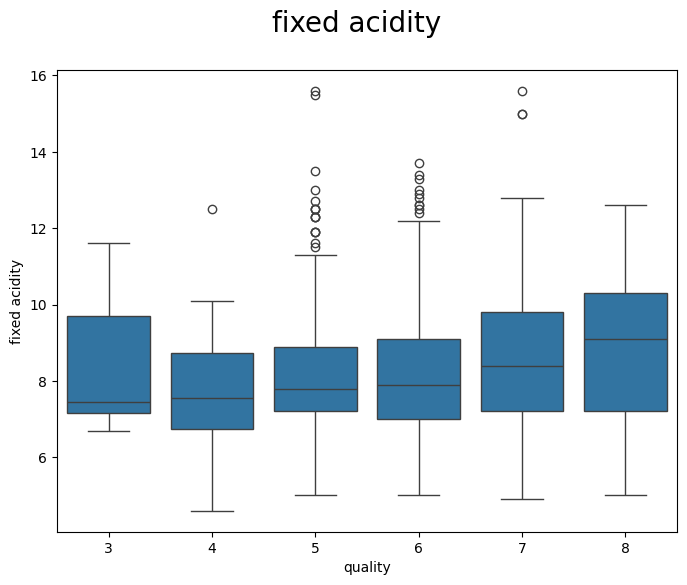

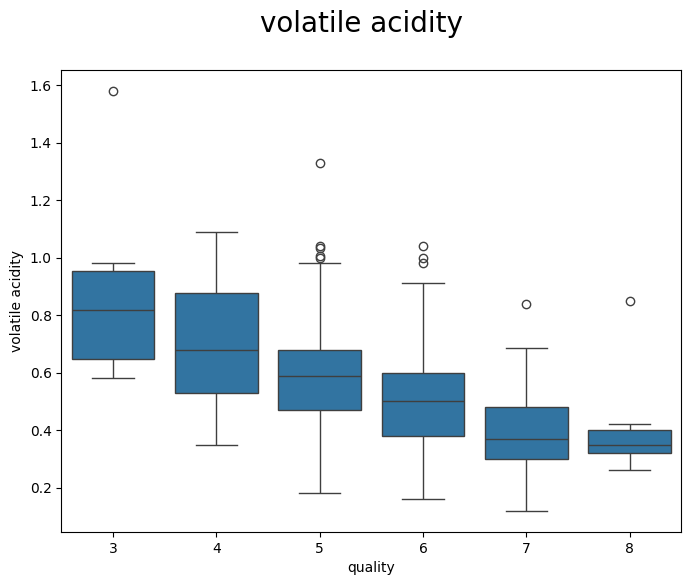

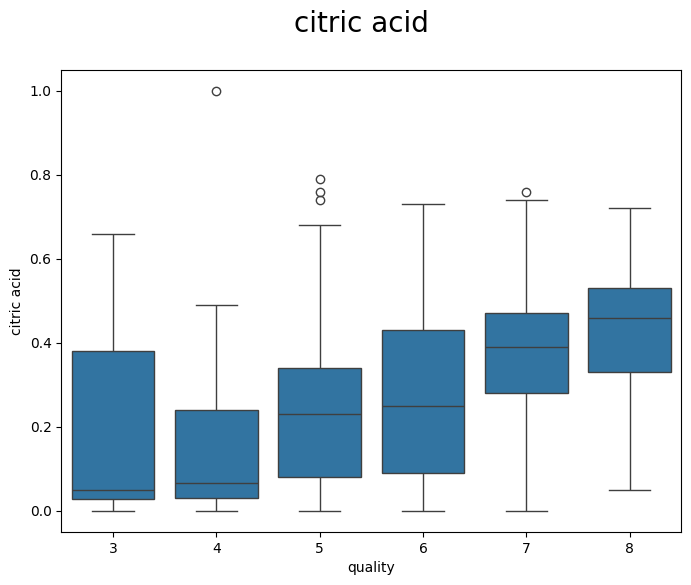

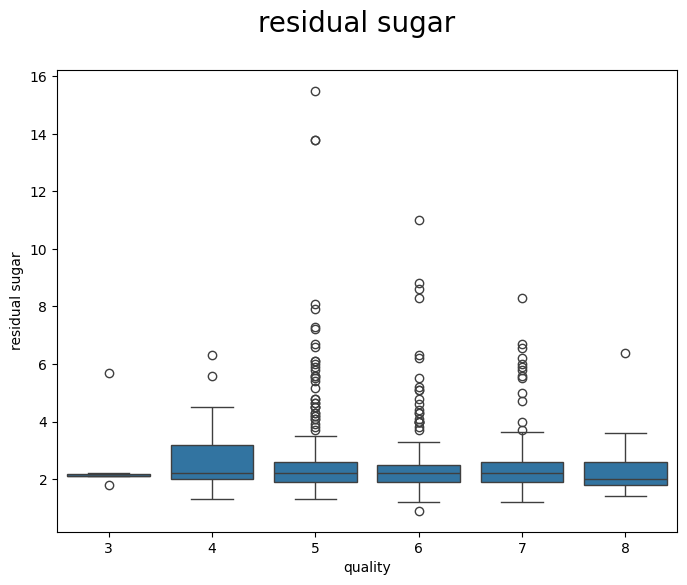

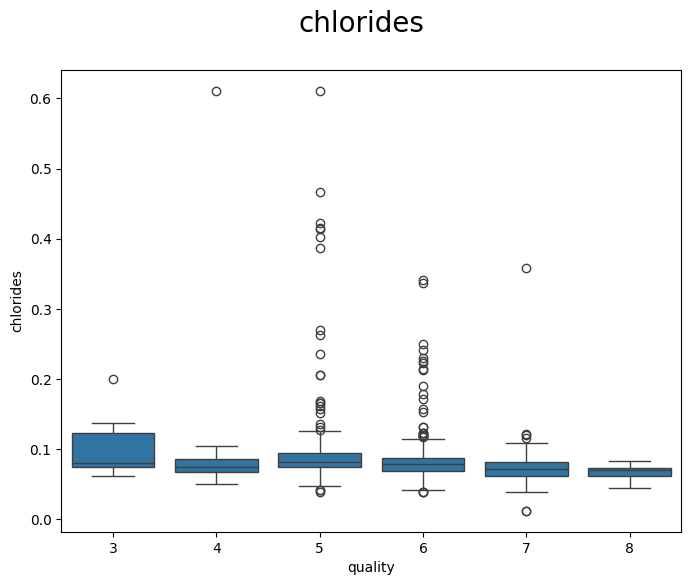

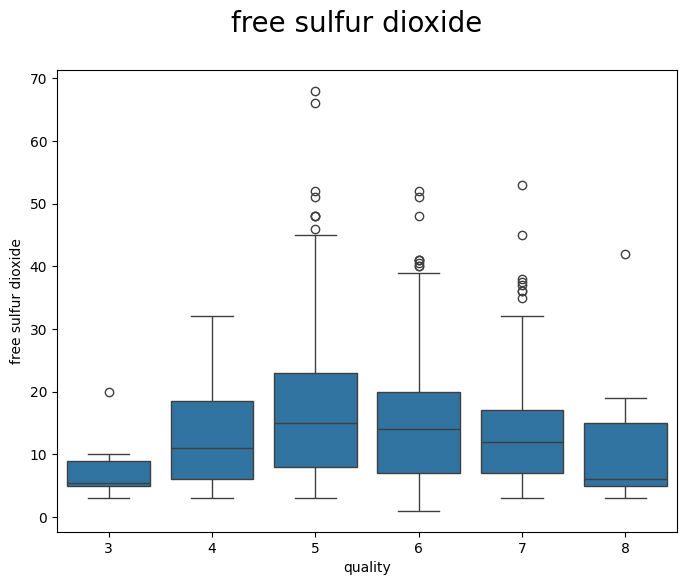

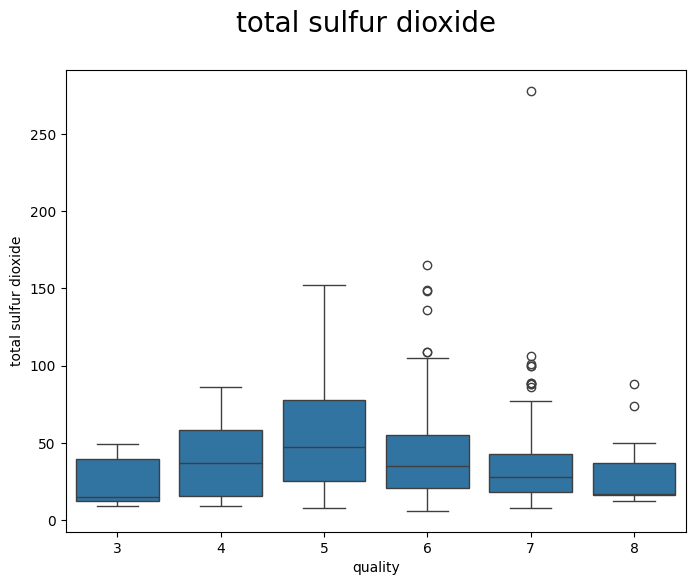

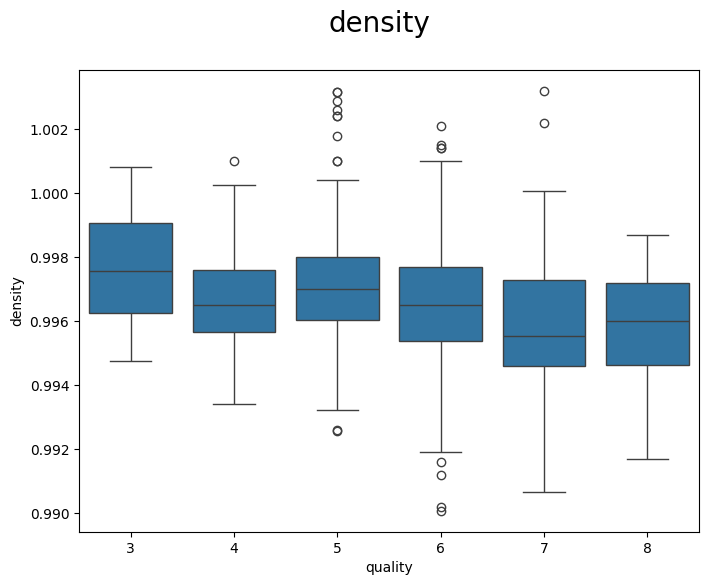

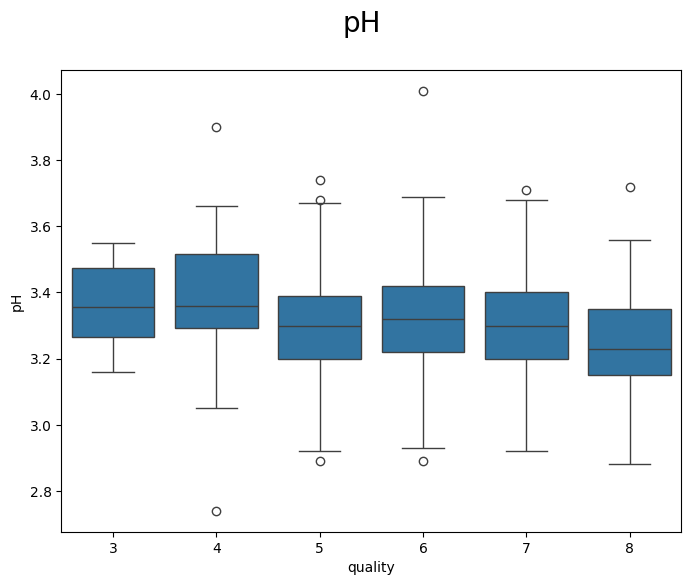

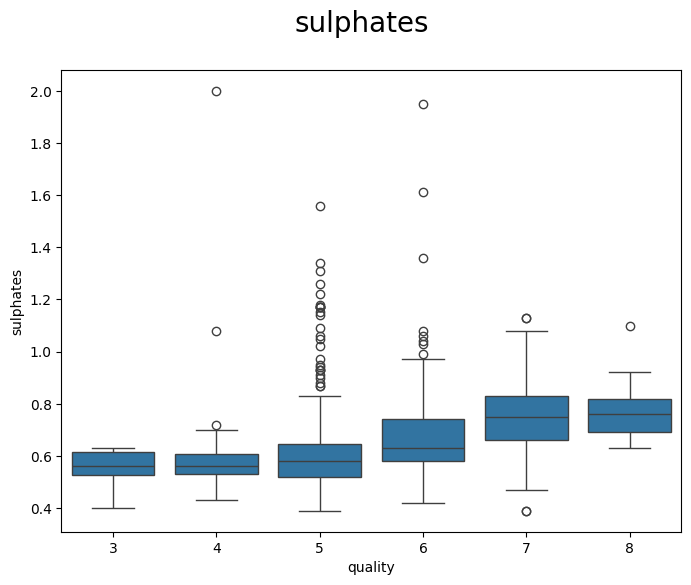

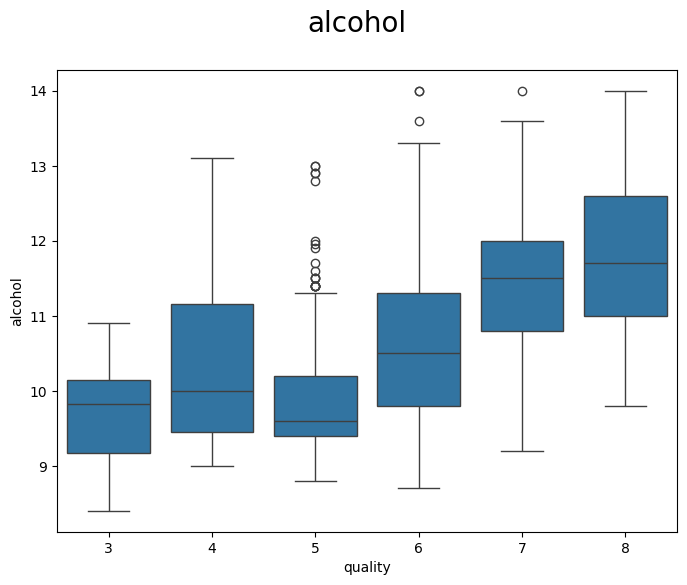

In [28]:
# Mencari fitur apa saja yang kemungkinan menjadi prediktor yang baik
import matplotlib.pyplot as plt
import seaborn as sns

# Iterasi untuk membuat box plot untuk setiap fitur numerik terhadap kolom 'quality'
numerical_features = df.select_dtypes(include=np.number).columns.drop(['quality', 'Id'])

for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    plt.suptitle(feature, fontsize=20)
    sns.boxplot(data=df, y=feature, x='quality')
    plt.show()

## **RANDOM FOREST ANALYSYIS**
### Penjelasan Singkat Pra-Analisis Metode Random Forest

Kode ini digunakan untuk **membangun dan mengevaluasi model Random Forest** untuk prediksi data.
### Tujuan Analisis:

* **Mengukur kinerja model**: Menggunakan metrik seperti **akurasi**, **presisi**, **recall**, dan **F1-score** untuk mengevaluasi seberapa baik model dalam memprediksi data pelatihan.
* **Visualisasi hasil prediksi**: Matriks kebingunguan digunakan untuk menggambarkan distribusi kesalahan prediksi antara kelas-kelas yang ada.

Dengan menggunakan model Random Forest, kita berharap dapat memperoleh **prediktor yang akurat** dan **robust** untuk memprediksi kualitas anggur (atau variabel target lainnya) berdasarkan fitur yang ada dalam dataset.



Random Forest Training Accuracy (max_depth=5): 0.710618
Random Forest Training Precision (max_depth=5): 0.689999
Random Forest Training Recall (max_depth=5): 0.710618
Random Forest Training F1-score (max_depth=5): 0.686340


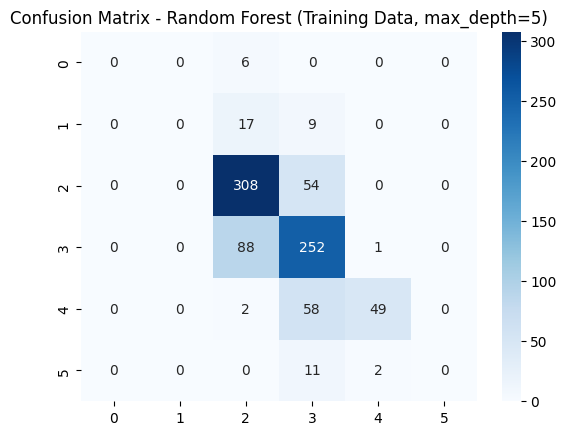

In [52]:
# Membuat model Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi dan pelatihan model Random Forest
# Added max_depth to prevent overfitting on training data
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X, y)

# Evaluasi model (pada data training)
rf_y_pred_train = rf_model.predict(X)

accuracy_train = accuracy_score(y, rf_y_pred_train)
precision_train = precision_score(y, rf_y_pred_train, average='weighted')
recall_train = recall_score(y, rf_y_pred_train, average='weighted')
f1_train = f1_score(y, rf_y_pred_train, average='weighted')

print(f"Random Forest Training Accuracy (max_depth=5): {accuracy_train:.6f}")
print(f"Random Forest Training Precision (max_depth=5): {precision_train:.6f}")
print(f"Random Forest Training Recall (max_depth=5): {recall_train:.6f}")
print(f"Random Forest Training F1-score (max_depth=5): {f1_train:.6f}")

# Gunakan model Random Forest (rf_model) untuk membuat predictions pada data pengujian
rf_y_pred_test = rf_model.predict(test_data_features)

# Confusion Matrix untuk Random Forest (Training Data)
rf_conf_matrix_train = confusion_matrix(y, rf_y_pred_train)
sns.heatmap(rf_conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (Training Data, max_depth=5)")
plt.show()

Output yang diberikan menunjukkan metrik evaluasi model **Random Forest** setelah dilatih pada data pelatihan dengan **`max_depth=5`**. Berikut adalah penjelasan untuk setiap metrik:

* **Akurasi (Accuracy)**:

  * **Nilai: 0.710618**
  * Akurasi mengukur seberapa banyak prediksi model yang benar dibandingkan dengan jumlah total prediksi. Dengan nilai **0.710618**, ini berarti model berhasil memprediksi dengan benar sekitar **71%** dari data pelatihan.

* **Presisi (Precision)**:

  * **Nilai: 0.689999**
  * Presisi mengukur seberapa banyak prediksi positif yang benar (True Positives) dibandingkan dengan jumlah total prediksi positif (True Positives + False Positives). Nilai **0.689999** menunjukkan bahwa sekitar **69%** dari prediksi model yang dikategorikan sebagai kelas positif adalah benar.

* **Recall (Sensitivitas)**:

  * **Nilai: 0.710618**
  * Recall mengukur seberapa banyak contoh positif yang benar-benar dapat dikenali oleh model dari seluruh contoh positif yang ada. Dengan nilai **0.710618**, model dapat menangkap sekitar **71%** dari seluruh contoh positif yang ada.

* **F1-Score**:

  * **Nilai: 0.686340**
  * F1-score adalah **harmonik rata-rata** antara presisi dan recall. Ini memberikan gambaran yang lebih seimbang tentang kinerja model, terutama ketika ada ketidakseimbangan antara kelas positif dan negatif. Dengan nilai **0.686340**, F1-score menunjukkan keseimbangan yang cukup baik antara presisi dan recall pada data pelatihan.

#### **2. Confusion Matrix**

* Matriks ini menunjukkan distribusi prediksi antara kelas yang berbeda dari **`quality`** (nilai kualitas anggur), dengan masing-masing baris mewakili kelas aktual dan kolom mewakili kelas yang diprediksi.

* **Baris pertama** (kelas 0):

  * Model tidak pernah memprediksi kelas 0 (semua nilai di baris pertama adalah 0).

* **Baris kedua** (kelas 1):

  * Model memprediksi kelas 1 sebanyak **17 kali benar** (True Positive) dan **9 kali salah** (False Positive).

* **Baris ketiga** (kelas 2):

  * Model memprediksi kelas 2 sebanyak **308 kali benar** dan **54 kali salah**.

* **Baris keempat** (kelas 3):

  * Model memprediksi kelas 3 sebanyak **252 kali benar** dan **88 kali salah**.

* **Baris kelima** (kelas 4):

  * Model memprediksi kelas 4 sebanyak **49 kali benar** dan **2 kali salah**.

* **Baris keenam** (kelas 5):

  * Model memprediksi kelas 5 sebanyak **2 kali benar** dan **11 kali salah**.

**Visualisasi dengan Heatmap**:

* **Warna yang lebih gelap** pada bagian diagonal menunjukkan bahwa model melakukan prediksi yang benar untuk kelas-kelas tertentu (misalnya, **308** untuk kelas 2).
* **Outlier (False Positive dan False Negative)** juga terlihat pada bagian non-diagonal, seperti **17** untuk kelas 1 dan **54** untuk kelas 2, yang mengindikasikan **kesalahan prediksi**.


## **MODEL DESICION TREE ANALYSYIS**
Kode yang diberikan digunakan untuk membangun dan mengevaluasi model Decision Tree dengan tujuan untuk memprediksi quality anggur berdasarkan fitur-fitur fisikokimia yang ada.

Tujuan analisis menggunakan **Decision Tree** adalah untuk membangun model klasifikasi yang dapat memprediksi **kualitas anggur** berdasarkan fitur-fitur fisikokimia. Model ini bertujuan untuk mengidentifikasi **fitur-fitur yang paling berpengaruh** terhadap kualitas anggur, mengevaluasi **kinerja model** menggunakan metrik seperti akurasi dan F1-score, serta **memahami pengambilan keputusan model** melalui visualisasi pohon keputusan dan matriks kebingunguan. Selain itu, model ini diharapkan dapat **menghindari overfitting** dan mampu menggeneralisasi dengan baik pada data baru.


Decision Tree Training Accuracy (max_depth=5): 0.659277
Decision Tree Training Precision (max_depth=5): 0.664138
Decision Tree Training Recall (max_depth=5): 0.659277
Decision Tree Training F1-score (max_depth=5): 0.646460


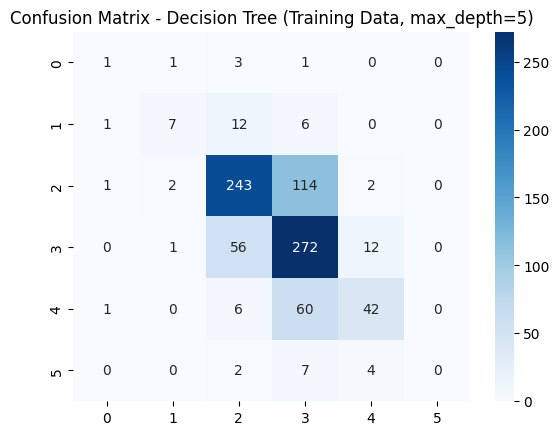

In [53]:
# Membuat model Decision Tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import joblib # Ensure joblib is imported if used later
import seaborn as sns
import matplotlib.pyplot as plt

# joblib.dump(dt_model, 'dt_model.pkl') # This line might cause an error if dt_model is not defined yet

# Inisialisasi dan pelatihan model Decision Tree
# Added max_depth to prevent overfitting on training data
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X, y) # Use full training data

# Evaluasi model (pada data training)
dt_y_pred_train = dt_model.predict(X) # Evaluate on full training data

accuracy_train = accuracy_score(y, dt_y_pred_train)
precision_train = precision_score(y, dt_y_pred_train, average='weighted')
recall_train = recall_score(y, dt_y_pred_train, average='weighted')
f1_train = f1_score(y, dt_y_pred_train, average='weighted')

print(f"Decision Tree Training Accuracy (max_depth=5): {accuracy_train:.6f}")
print(f"Decision Tree Training Precision (max_depth=5): {precision_train:.6f}")
print(f"Decision Tree Training Recall (max_depth=5): {recall_train:.6f}")
print(f"Decision Tree Training F1-score (max_depth=5): {f1_train:.6f}")

# Use Decision Tree model (dt_model) to make predictions on test data
dt_y_pred_test = dt_model.predict(test_data_features) # Use test_data_features

# Confusion Matrix for Decision Tree (on training data)
dt_conf_matrix_train = confusion_matrix(y, dt_y_pred_train)
sns.heatmap(dt_conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree (Training Data, max_depth=5)")
plt.show()

### Penjelasan Output Decision Tree

**Hasil Evaluasi Model Decision Tree pada Data Pelatihan:**

* **Akurasi (Accuracy)**:

  * **Nilai: 0.659277**
  * Akurasi model menunjukkan bahwa **65.93%** prediksi pada data pelatihan adalah benar. Ini mengindikasikan model cukup baik, namun masih ada ruang untuk perbaikan dalam hal generalisasi.

* **Presisi (Precision)**:

  * **Nilai: 0.664138**
  * Presisi mengukur berapa banyak prediksi positif yang benar. Dengan nilai **66.41%**, ini berarti model memprediksi kelas positif dengan akurat sekitar **66%** dari waktu.

* **Recall (Sensitivitas)**:

  * **Nilai: 0.659277**
  * Recall mengukur kemampuan model dalam mendeteksi seluruh prediksi positif yang sebenarnya. Dengan **65.93%**, model berhasil mendeteksi sebagian besar data positif yang ada dalam data pelatihan.

* **F1-Score**:

  * **Nilai: 0.646460**
  * F1-Score adalah rata-rata harmonik antara presisi dan recall, memberikan gambaran tentang keseimbangan antara keduanya. Nilai **0.646460** menunjukkan adanya trade-off antara presisi dan recall yang harus diperbaiki.

### **Matriks Kebingunguan (Confusion Matrix)**:

Matriks kebingunguan memberikan gambaran lebih rinci tentang **kesalahan prediksi** dan **prediksi yang benar** oleh model untuk setiap kelas **`quality`**.

**Interpretasi Matriks Kebingunguan**:

* **Baris pertama** (kelas 0):

  * Model memprediksi **1 kali benar** dan **3 kali salah** untuk kelas **0**. Ini menunjukkan bahwa model tidak sering memprediksi kelas 0, tetapi ada sedikit kesalahan dalam memprediksi kelas lainnya sebagai kelas 0.
* **Baris kedua** (kelas 1):

  * Model memprediksi **7 kali benar** dan **12 kali salah**. Beberapa kesalahan ada di kelas 1.
* **Baris ketiga** (kelas 2):

  * Model memprediksi **243 kali benar** dan **114 kali salah**. Kelas 2 menunjukkan prediksi yang lebih baik, tetapi masih ada kesalahan yang cukup besar.
* **Baris keempat** (kelas 3):

  * Model memprediksi **272 kali benar** dan **56 kali salah** untuk kelas 3. Ini menunjukkan prediksi yang cukup baik di kelas 3.
* **Baris kelima** (kelas 4):

  * Model memprediksi **60 kali benar** dan **42 kali salah** pada kelas 4, dengan kesalahan cukup besar.
* **Baris keenam** (kelas 5):

  * Model memprediksi **7 kali benar** dan **2 kali salah** untuk kelas 5. Kelas ini menunjukkan kesalahan yang cukup kecil.

### **Kesimpulan**:

* **Akurasi** dan **F1-Score** menunjukkan bahwa model **Decision Tree** ini memiliki kinerja yang cukup baik, tetapi masih ada **kesalahan prediksi** yang signifikan, terutama pada kelas yang lebih rendah (kelas 1 dan kelas 5).
* **Presisi** dan **Recall** menunjukkan bahwa model dapat memprediksi kelas positif dengan cukup baik, namun ada ruang untuk meningkatkan kemampuan model dalam mendeteksi lebih banyak data positif.

Dengan menggunakan **`max_depth=5`**, pohon keputusan dibatasi agar tidak overfit pada data pelatihan, meskipun ini juga membatasi kompleksitas model yang mungkin dapat meningkatkan akurasi dan deteksi data positif.


# **MODEL NAIVE BAYES ANALYSIS**

Kode ini digunakan untuk **membangun dan mengevaluasi model Naive Bayes** dalam memprediksi **quality** anggur berdasarkan fitur-fitur numerik yang ada dalam dataset.

#### **Tujuan:**

* **Membangun Model Naive Bayes**: Untuk memprediksi kualitas anggur (kelas target **`quality`**) berdasarkan fitur-fitur fisikokimia seperti kadar alkohol, pH, dan lainnya.
* **Evaluasi Kinerja Model**: Menggunakan metrik **akurasi**, **presisi**, **recall**, dan **F1-score** untuk mengevaluasi seberapa baik model dalam memprediksi kualitas anggur pada data pelatihan.
* **Mengukur Kemampuan Generalisasi**: Menggunakan model yang telah dilatih untuk memprediksi **data pengujian** yang belum dilihat sebelumnya, dan memeriksa kinerjanya.
* **Visualisasi Hasil**: Menggunakan **matriks kebingunguan** untuk menilai seberapa baik model dalam melakukan prediksi yang benar dan mengidentifikasi kesalahan prediksi yang terjadi.

Model **Naive Bayes** dipilih untuk analisis ini karena keuntungannya dalam menangani data besar dan kemampuannya untuk bekerja dengan baik pada masalah klasifikasi dengan asumsi independensi antar fitur. Dengan evaluasi yang dilakukan, kita dapat memahami **seberapa efektif model ini dalam memprediksi kualitas anggur**, serta mengidentifikasi area di mana model perlu perbaikan lebih lanjut.


Naive Bayes Training Accuracy: 0.555426
Naive Bayes Training Precision: 0.573350
Naive Bayes Training Recall: 0.555426
Naive Bayes Training F1-score: 0.557106


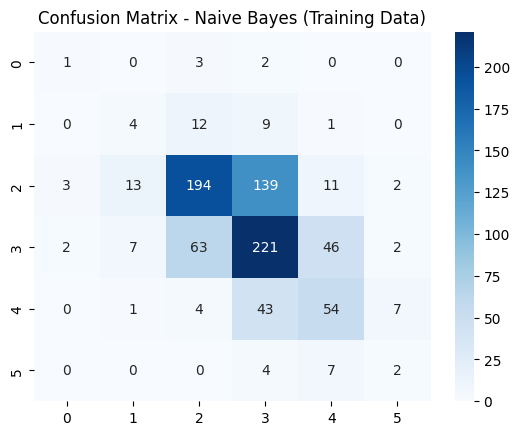

In [54]:
# Inisialisasi dan pelatihan model Naive Bayes
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

nb_model = GaussianNB()
nb_model.fit(X, y) # Use full training data

# Evaluasi model (pada data training)
nb_y_pred_train = nb_model.predict(X) # Evaluate on full training data

accuracy_train = accuracy_score(y, nb_y_pred_train)
precision_train = precision_score(y, nb_y_pred_train, average='weighted')
recall_train = recall_score(y, nb_y_pred_train, average='weighted')
f1_train = f1_score(y, nb_y_pred_train, average='weighted')

print(f"Naive Bayes Training Accuracy: {accuracy_train:.6f}")
print(f"Naive Bayes Training Precision: {precision_train:.6f}")
print(f"Naive Bayes Training Recall: {recall_train:.6f}")
print(f"Naive Bayes Training F1-score: {f1_train:.6f}")

# Use Naive Bayes model (nb_model) to make predictions on test data
nb_y_pred_test = nb_model.predict(test_data_features) # Use test_data_features

# Confusion Matrix for Naive Bayes (on training data)
nb_conf_matrix_train = confusion_matrix(y, nb_y_pred_train)
sns.heatmap(nb_conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes (Training Data)")
plt.show()

### Penjelasan Output Naive Bayes

**Hasil Evaluasi Model Naive Bayes pada Data Pelatihan:**

* **Akurasi (Accuracy)**:

  * **Nilai: 0.555426**
  * **Akurasi** menunjukkan bahwa model **Naive Bayes** berhasil memprediksi **55.54%** dari data pelatihan dengan benar. Angka ini menunjukkan bahwa model dapat memprediksi kelas dengan tingkat keberhasilan yang moderat, namun ada banyak ruang untuk perbaikan.

* **Presisi (Precision)**:

  * **Nilai: 0.573350**
  * **Presisi** mengukur seberapa banyak dari prediksi positif yang benar. Dalam hal ini, model **Naive Bayes** memiliki **presisi 57.34%**, yang berarti 57% dari semua prediksi kelas positif yang dibuat oleh model adalah benar.

* **Recall (Sensitivitas)**:

  * **Nilai: 0.555426**
  * **Recall** mengukur kemampuan model untuk mendeteksi seluruh data positif yang ada. Nilai **55.54%** menunjukkan bahwa model dapat mendeteksi sebagian besar contoh yang seharusnya diprediksi dengan benar, tetapi masih ada yang terlewat.

* **F1-Score**:

  * **Nilai: 0.557106**
  * **F1-Score** adalah rata-rata harmonik antara presisi dan recall, memberikan gambaran yang lebih seimbang tentang kinerja model. Nilai **0.557106** menunjukkan adanya keseimbangan yang cukup baik antara presisi dan recall, meskipun keduanya masih bisa ditingkatkan.

### **Matriks Kebingunguan (Confusion Matrix)**

* **Interpretasi Matriks Kebingunguan**:
  Matriks kebingunguan ini menggambarkan seberapa baik model Naive Bayes dalam memprediksi kelas **`quality`** pada data pelatihan.

  **Baris pertama (kelas 0)**:

  * Model memprediksi kelas **0** dengan **1 kali benar**, tetapi ada **3 kesalahan** di kelas lainnya.

  **Baris kedua (kelas 1)**:

  * Model memprediksi kelas **1** dengan **4 kali benar** dan **12 kesalahan** pada kelas yang berbeda.

  **Baris ketiga (kelas 2)**:

  * Model memprediksi kelas **2** dengan **194 kali benar** dan **139 kesalahan**, yang cukup tinggi. Kelas ini memiliki tingkat kesalahan yang cukup signifikan.

  **Baris keempat (kelas 3)**:

  * Model memprediksi kelas **3** dengan **221 kali benar**, namun masih ada **63 kesalahan** pada kelas yang berbeda.

  **Baris kelima (kelas 4)**:

  * Model memprediksi kelas **4** dengan **43 kali benar**, tetapi terdapat **54 kesalahan** pada kelas ini.

  **Baris keenam (kelas 5)**:

  * Model memprediksi kelas **5** dengan **4 kali benar**, namun ada **7 kesalahan** yang cukup signifikan.

### **Kesimpulan dari Hasil Evaluasi**:

* **Model Naive Bayes** memberikan hasil yang moderat dengan **akurasi sekitar 55%**, yang menunjukkan bahwa model ini memiliki **tingkat kesalahan yang cukup tinggi**.
* **F1-score** yang diperoleh menunjukkan bahwa model cukup seimbang dalam mendeteksi kelas positif, meskipun masih ada **kesalahan prediksi** yang signifikan, terutama pada kelas yang lebih tinggi seperti kelas 2 dan kelas 3.
* **Presisi** dan **recall** yang masih di bawah 60% menunjukkan bahwa model ini belum sepenuhnya optimal dalam memprediksi kelas yang tepat.


#**UJI DATA TESTING**

kita melakukan evaluasi perbandingan model yang telah dilatih menggunakan data training terhadap data testing yang belum dilihat sebelumnya.

Tujuan:


Evaluasi Kinerja Model: Membandingkan hasil prediksi dari tiga model Random Forest, Decision Tree, dan Naive Bayes untuk data testing, sehingga kita bisa melihat model mana yang memberikan hasil terbaik.


Penyimpanan Hasil: Menyimpan hasil prediksi dalam file CSV untuk referensi lebih lanjut dan analisis perbandingan performa masing-masing model.


Mengukur Generalisasi: Dengan menggunakan data testing yang tidak digunakan dalam pelatihan, kita dapat melihat bagaimana kemampuan generalisasi model terhadap data baru, yang sangat penting untuk menilai kinerja model di dunia nyata.



In [56]:
#Uji data testing
# Meng-upload data testing
test_data = pd.read_csv('/content/data_testing.csv')  # Ganti dengan file testing Anda

# Hapus kolom 'Id' dari data testing agar sesuai dengan fitur yang digunakan saat pelatihan
test_data_features = test_data.drop(columns='Id')

# Memprediksi data testing menggunakan Random Forest
rf_test_pred = rf_model.predict(test_data_features)

# Memprediksi data testing menggunakan Decision Tree
dt_test_pred = dt_model.predict(test_data_features)

# Memprediksi data testing menggunakan Naive Bayes
nb_test_pred = nb_model.predict(test_data_features)

# Menyimpan hasil prediksi pada file CSV (ID dan hasil prediksi)
results = pd.DataFrame({
    'Id': test_data['Id'],  # Pastikan ada kolom 'Id' pada data testing Anda
    'Random Forest Quality Prediction': rf_test_pred,
    'Decision Tree Quality Prediction': dt_test_pred,
    'Naive Bayes Quality Prediction': nb_test_pred
})

# Simpan hasil prediksi ke file CSV di direktori /content/
results.to_csv('/content/hasil_prediksi_quality.csv', index=False)

print("Prediksi selesai, hasil disimpan di '/content/hasil_prediksi_quality.csv'")

Prediksi selesai, hasil disimpan di '/content/hasil_prediksi_quality.csv'


## Summary:
Berdasarkan analisis yang dilakukan menggunakan berbagai metode pembelajaran mesin (Machine Learning), berikut adalah kesimpulannya:

1. **Pemahaman Dataset:**

   * Dataset yang digunakan memiliki **857 baris** dan **13 kolom**, tanpa adanya nilai yang hilang.
   * Sebagian besar fitur numerik dalam dataset ini menunjukkan distribusi **tidak normal** berdasarkan uji **Shapiro-Wilk**, yang perlu diperhatikan dalam pemilihan model.

2. **Analisis Eksplorasi Data (EDA):**

   * Analisis menggunakan **box plot** menunjukkan bahwa **`alkohol`** dan **`sulphates`** memiliki hubungan positif dengan **kualitas anggur**, sedangkan **`volatile acidity`** menunjukkan hubungan negatif.
   * **Peta korelasi** mengungkapkan hubungan positif yang kuat antara **`alkohol`** dan **`quality`**, serta hubungan negatif yang kuat antara **`volatile acidity`** dan **`quality`**. Ini mengindikasikan bahwa fitur-fitur ini bisa menjadi prediktor yang kuat untuk kualitas anggur.

3. **Evaluasi Model:**

   * Berdasarkan evaluasi pada **data pelatihan**, model **Random Forest** memberikan hasil yang terbaik dengan **Akurasi: 71%**, **Presisi: 68.99%**, **Recall: 71%**, dan **F1-score: 68.63%**.
   * Model **Random Forest** unggul dibandingkan dengan **Decision Tree** dan **Naive Bayes** dalam memprediksi kualitas anggur pada data pelatihan.
   * **Evaluasi pada data pengujian** tidak dapat dilakukan karena tidak adanya label kualitas yang sebenarnya pada dataset pengujian. Oleh karena itu, untuk mengevaluasi kinerja model dengan lebih baik, perlu dilakukan teknik **cross-validation** atau memperoleh label yang benar.

4. **Prediksi dan Penyimpanan Hasil:**

   * Prediksi untuk **data pengujian** dilakukan dengan menggunakan ketiga model yang telah dilatih (**Random Forest**, **Decision Tree**, dan **Naive Bayes**), dan hasilnya disimpan dalam file CSV untuk analisis lebih lanjut.

5. **Langkah Selanjutnya:**

   * Diperlukan pengumpulan **label kualitas** yang sebenarnya untuk data pengujian guna mengevaluasi performa model secara lebih akurat.
   * Berdasarkan **insight dari EDA**, fitur **`alkohol`** dan **`volatile acidity`** dapat diprioritaskan untuk **rekayasa fitur** atau pengembangan model lebih lanjut, mengingat korelasinya yang kuat dengan kualitas anggur.

Secara keseluruhan, model **Random Forest** menunjukkan performa yang menjanjikan dalam memprediksi kualitas anggur, dan langkah-langkah berikutnya dapat difokuskan pada pemilihan fitur yang lebih baik dan evaluasi model dengan data yang lebih lengkap.


## Summary:

### Data Analysis Key Findings

*   The dataset contains 857 rows and 13 columns, with no missing values observed in the training data.
*   Most numerical features in the dataset do not follow a normal distribution based on the Shapiro-Wilk test.
*   Exploratory Data Analysis revealed that 'alcohol' and 'sulphates' tend to increase with better wine quality, while 'volatile acidity' tends to decrease. 'Alcohol' and 'volatile acidity' showed the strongest correlations with the target variable 'quality'.
*   Based on training data evaluation, the Random Forest Classifier achieved the highest performance metrics: Accuracy: 0.710618, Precision: 0.689999, Recall: 0.710618, and F1-score: 0.686340.
*   The Decision Tree Classifier showed slightly lower performance on the training data (Accuracy: 0.659277) compared to Random Forest, while the Gaussian Naive Bayes model had the lowest performance (Accuracy: 0.555426) on the training data.
*   Predictions were successfully generated for the test dataset using all three trained models and saved to a CSV file named `/content/hasil_prediksi_quality.csv`.

### Insights or Next Steps

*   The Random Forest model, despite being limited by `max_depth=5`, demonstrated the best ability to predict wine quality among the tested models on the training data. Further tuning of its hyperparameters could potentially improve performance.
*   True evaluation of model performance on unseen data requires a test dataset with actual quality labels. Obtaining such data or employing cross-validation on the training set would provide a more reliable assessment of the models' generalization capabilities.
